✅ Columns OK
✅ Simulation completed


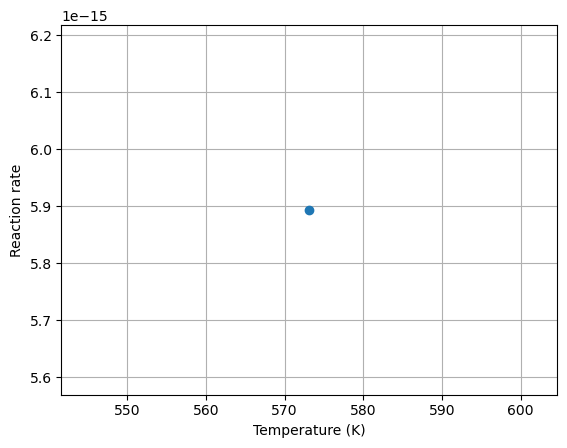

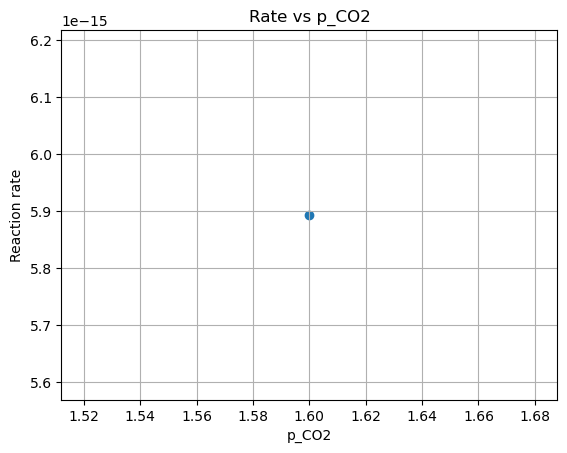

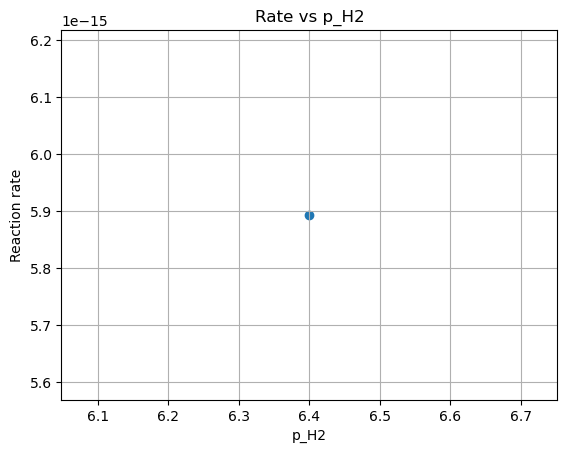

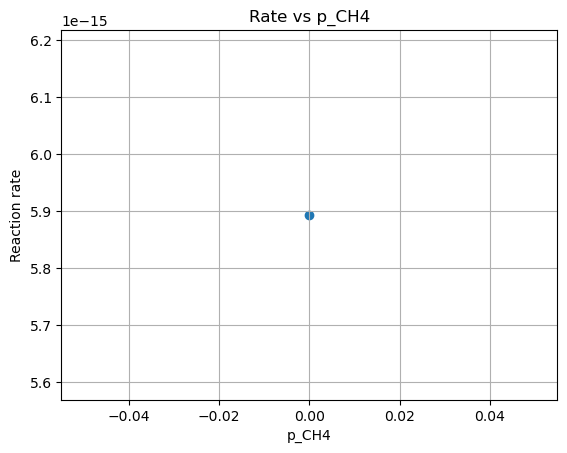

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Koz = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Koz")

# ===============================
# Normalize column names
# ===============================
df_Koz.columns = (
    df_Koz.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ---- Explicit mapping (CRITICAL) ----
column_map = {
    "k0": "k0",
    "kzero": "k0",
    "k₀": "k0",
    "ea": "Ea",
    "t": "T",
    "aoh": "Aoh",
    "boh": "Boh",
    "ah2": "Ah2",
    "bh2": "Bh2",
    "aeq": "Aeq",
    "beq": "Beq",
    "ceq": "Ceq",
    "amix": "Amix",
    "bmix": "Bmix",
    "ph2": "p_H2",
    "pco2": "p_CO2",
    "pch4": "p_CH4",
    "ph2o": "p_H2O",
}

df_Koz = df_Koz.rename(columns={k: v for k, v in column_map.items() if k in df_Koz.columns})

# ===============================
# Sanity check (FAIL FAST)
# ===============================
required = [
    "k0", "Ea", "T",
    "Aeq", "Beq", "Ceq",
    "Aoh", "Boh",
    "Ah2", "Bh2",
    "Amix", "Bmix",
    "p_H2", "p_CO2", "p_CH4", "p_H2O"
]

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")

print("✅ Columns OK")

# ===============================
# Koz methanation rate
# ===============================
def co2_methanation_rate(row):
    T = row["T"]

    k = row["k0"] * np.exp(-row["Ea"] / (R * T))

    K_eq = np.exp(row["Aeq"] + row["Beq"]/T - row["Ceq"]*np.log(T))
    K_OH = np.exp(row["Aoh"] + row["Boh"]/T)
    K_H2 = np.exp(row["Ah2"] + row["Bh2"]/T)
    K_mix = np.exp(row["Amix"] + row["Bmix"]/T)

    driving_force = 1.0 - (
        row["p_CH4"] * row["p_H2O"]**2
    ) / (
        row["p_CO2"] * row["p_H2"]**4 * K_eq
    )

    numerator = (
        k
        * row["p_H2"]**0.5
        * row["p_CO2"]**0.5
        * driving_force
    )

    denominator = (
        1
        + K_OH * (row["p_H2O"] / row["p_H2"]**0.5)
        + K_H2 * row["p_H2"]**0.5
        + K_mix * row["p_CO2"]**0.5
    )**2

    return numerator / denominator

# ===============================
# Run simulations
# ===============================
df_Koz["rate"] = df_Koz.apply(co2_methanation_rate, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_Koz.to_excel(writer, sheet_name="Koz_Results", index=False)


print("✅ Simulation completed")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Koz["T"], df_Koz["rate"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.show()

# Rate vs p_CO2
plt.figure()
plt.scatter(df_Koz["p_CO2"], df_Koz["rate"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.title("Rate vs p_CO2")
plt.grid(True)
plt.show()

# Rate vs p_H2
plt.figure()
plt.scatter(df_Koz["p_H2"], df_Koz["rate"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.title("Rate vs p_H2")
plt.grid(True)
plt.show()

# Rate vs p_CH4
plt.figure()
plt.scatter(df_Koz["p_CH4"], df_Koz["rate"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.title("Rate vs p_CH4")
plt.grid(True)
plt.show()

✅ Columns OK
✅ Simulation completed


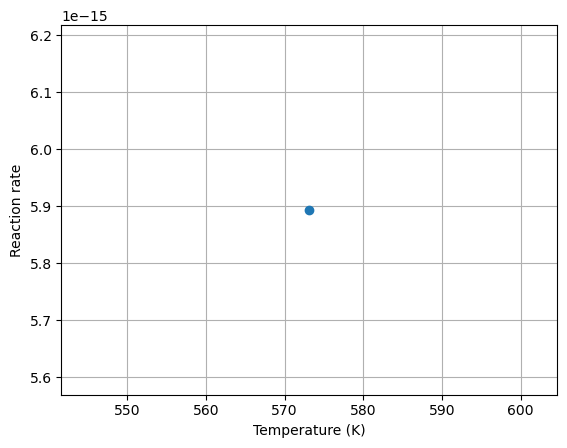

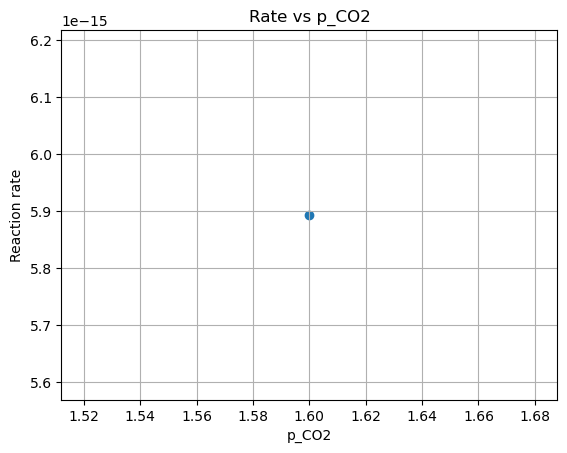

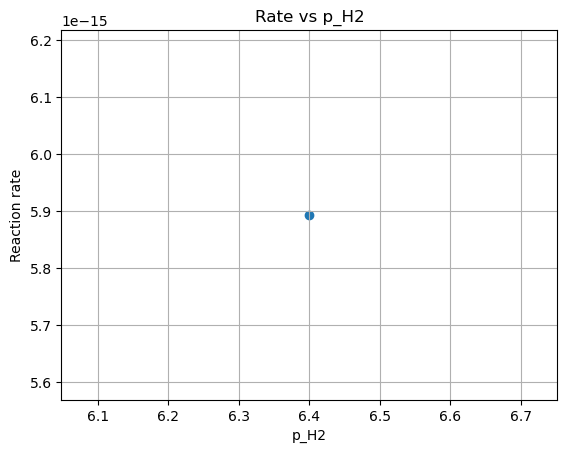

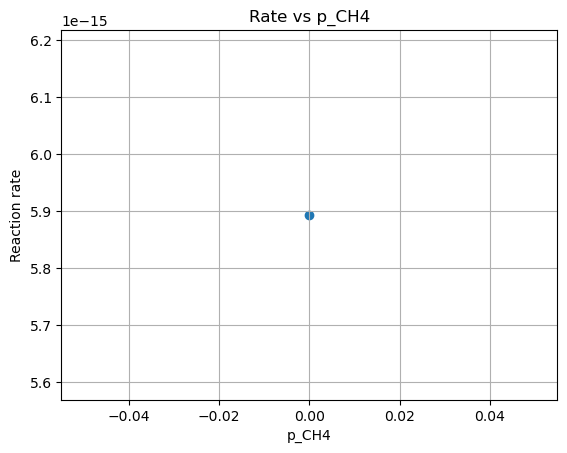

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Koz = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Koz")

# ===============================
# Normalize column names
# ===============================
df_Koz.columns = (
    df_Koz.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ---- Explicit mapping (CRITICAL) ----
column_map = {
    "k0": "k0",
    "kzero": "k0",
    "k₀": "k0",
    "ea": "Ea",
    "t": "T",
    "aoh": "Aoh",
    "boh": "Boh",
    "ah2": "Ah2",
    "bh2": "Bh2",
    "aeq": "Aeq",
    "beq": "Beq",
    "ceq": "Ceq",
    "amix": "Amix",
    "bmix": "Bmix",
    "ph2": "p_H2",
    "pco2": "p_CO2",
    "pch4": "p_CH4",
    "ph2o": "p_H2O",
}

df_Koz = df_Koz.rename(columns={k: v for k, v in column_map.items() if k in df_Koz.columns})

# ===============================
# Sanity check (FAIL FAST)
# ===============================
required = [
    "k0", "Ea", "T",
    "Aeq", "Beq", "Ceq",
    "Aoh", "Boh",
    "Ah2", "Bh2",
    "Amix", "Bmix",
    "p_H2", "p_CO2", "p_CH4", "p_H2O"
]

missing = [c for c in required if c not in df_Koz.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")

print("✅ Columns OK")

# ===============================
# Koz methanation rate
# ===============================
def co2_methanation_rate(row):
    T = row["T"]

    k = row["k0"] * np.exp(-row["Ea"] / (R * T))

    K_eq = np.exp(row["Aeq"] + row["Beq"]/T - row["Ceq"]*np.log(T))
    K_OH = np.exp(row["Aoh"] + row["Boh"]/T)
    K_H2 = np.exp(row["Ah2"] + row["Bh2"]/T)
    K_mix = np.exp(row["Amix"] + row["Bmix"]/T)

    driving_force = 1.0 - (
        row["p_CH4"] * row["p_H2O"]**2
    ) / (
        row["p_CO2"] * row["p_H2"]**4 * K_eq
    )

    numerator = (
        k
        * row["p_H2"]**0.5
        * row["p_CO2"]**0.5
        * driving_force
    )

    denominator = (
        1
        + K_OH * (row["p_H2O"] / row["p_H2"]**0.5)
        + K_H2 * row["p_H2"]**0.5
        + K_mix * row["p_CO2"]**0.5
    )**2

    return numerator / denominator

# ===============================
# Run simulations
# ===============================
df_Koz["rate"] = df_Koz.apply(co2_methanation_rate, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_Koz.to_excel(writer, sheet_name="Koz_Results", index=False)


print("✅ Simulation completed")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Koz["T"], df_Koz["rate"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.show()

# Rate vs p_CO2
plt.figure()
plt.scatter(df_Koz["p_CO2"], df_Koz["rate"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.title("Rate vs p_CO2")
plt.grid(True)
plt.show()

# Rate vs p_H2
plt.figure()
plt.scatter(df_Koz["p_H2"], df_Koz["rate"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.title("Rate vs p_H2")
plt.grid(True)
plt.show()

# Rate vs p_CH4
plt.figure()
plt.scatter(df_Koz["p_CH4"], df_Koz["rate"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.title("Rate vs p_CH4")
plt.grid(True)
plt.show()

✅ Columns OK | Rows before cleaning: 38
✅ Rows after cleaning: 1
✅ Simulation completed


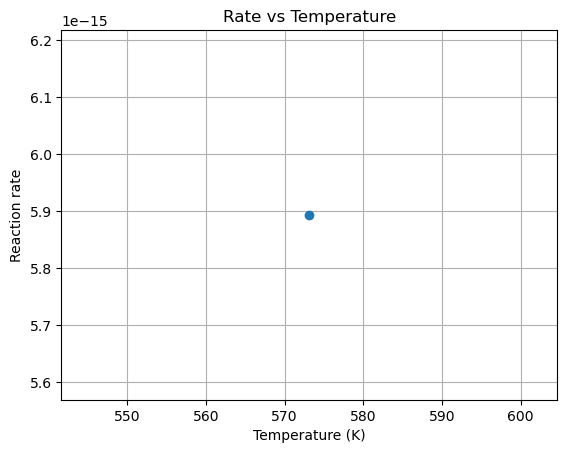

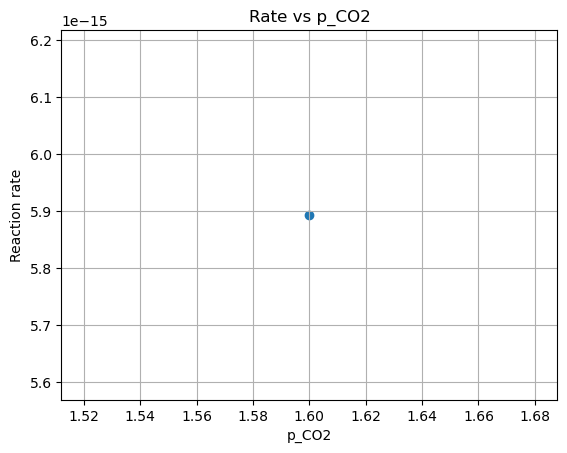

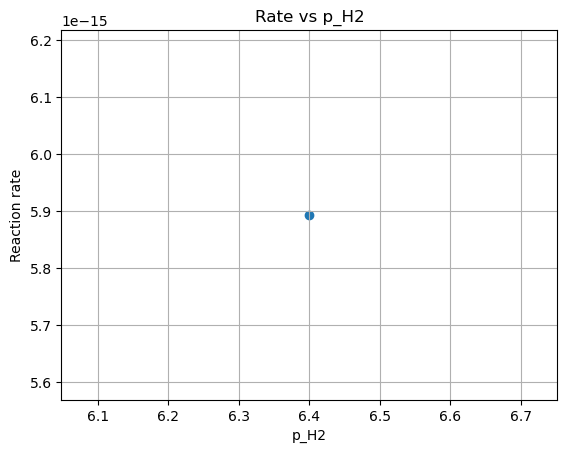

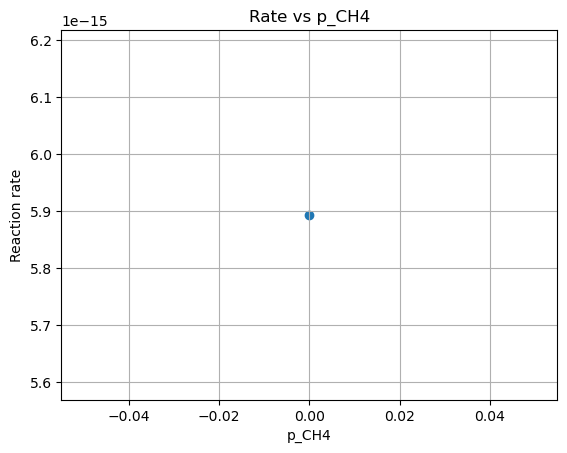

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Koz = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Koz")

# ===============================
# Normalize column names
# ===============================
df_Koz.columns = (
    df_Koz.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ---- Explicit mapping ----
column_map = {
    "k0": "k0",
    "kzero": "k0",
    "k₀": "k0",
    "ea": "Ea",
    "t": "T",
    "aoh": "Aoh",
    "boh": "Boh",
    "ah2": "Ah2",
    "bh2": "Bh2",
    "aeq": "Aeq",
    "beq": "Beq",
    "ceq": "Ceq",
    "amix": "Amix",
    "bmix": "Bmix",
    "ph2": "p_H2",
    "pco2": "p_CO2",
    "pch4": "p_CH4",
    "ph2o": "p_H2O",
}

df_Koz = df_Koz.rename(columns={k: v for k, v in column_map.items() if k in df_Koz.columns})

# ===============================
# Required columns
# ===============================
required = [
    "k0", "Ea", "T",
    "Aeq", "Beq", "Ceq",
    "Aoh", "Boh",
    "Ah2", "Bh2",
    "Amix", "Bmix",
    "p_H2", "p_CO2", "p_CH4", "p_H2O"
]

# ===============================
# Sanity check
# ===============================
missing = [c for c in required if c not in df_Koz.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")
print(f"✅ Columns OK | Rows before cleaning: {len(df_Koz)}")

# ===============================
# Force numeric
# ===============================
df_Koz[required] = df_Koz[required].apply(pd.to_numeric, errors="coerce")
df_Koz = df_Koz.dropna(subset=required).reset_index(drop=True)
print(f"✅ Rows after cleaning: {len(df_Koz)}")

# ===============================
# Koz methanation rate function
# ===============================
def co2_methanation_rate(row):
    T = row["T"]
    k = row["k0"] * np.exp(-row["Ea"] / (R * T))

    K_eq = np.exp(row["Aeq"] + row["Beq"]/T - row["Ceq"]*np.log(T))
    K_OH = np.exp(row["Aoh"] + row["Boh"]/T)
    K_H2 = np.exp(row["Ah2"] + row["Bh2"]/T)
    K_mix = np.exp(row["Amix"] + row["Bmix"]/T)

    driving_force = 1.0 - (
        row["p_CH4"] * row["p_H2O"]**2
    ) / (
        row["p_CO2"] * row["p_H2"]**4 * K_eq
    )

    numerator = (
        k
        * row["p_H2"]**0.5
        * row["p_CO2"]**0.5
        * driving_force
    )

    denominator = (
        1
        + K_OH * (row["p_H2O"] / row["p_H2"]**0.5)
        + K_H2 * row["p_H2"]**0.5
        + K_mix * row["p_CO2"]**0.5
    )**2

    return numerator / denominator

# ===============================
# Run simulations
# ===============================
df_Koz["rate"] = df_Koz.apply(co2_methanation_rate, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_Koz.to_excel(writer, sheet_name="Koz_Results", index=False)

print("✅ Simulation completed")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Koz["T"], df_Koz["rate"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs Temperature")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CO2"], df_Koz["rate"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CO2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_H2"], df_Koz["rate"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_H2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CH4"], df_Koz["rate"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CH4")
plt.show()

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Koz = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Koz")

# ===============================
# Normalize column names
# ===============================
df_Koz.columns = (
    df_Koz.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ---- Explicit mapping ----
column_map = {
    "k0": "k0",
    "kzero": "k0",
    "k₀": "k0",
    "ea": "Ea",
    "t": "T",
    "aoh": "Aoh",
    "boh": "Boh",
    "ah2": "Ah2",
    "bh2": "Bh2",
    "aeq": "Aeq",
    "beq": "Beq",
    "ceq": "Ceq",
    "amix": "Amix",
    "bmix": "Bmix",
    "ph2": "p_H2",
    "pco2": "p_CO2",
    "pch4": "p_CH4",
    "ph2o": "p_H2O",
}

df_Koz = df_Koz.rename(columns={k: v for k, v in column_map.items() if k in df_Koz.columns})

# ===============================
# Required columns
# ===============================
required = [
    "k0", "Ea", "T",
    "Aeq", "Beq", "Ceq",
    "Aoh", "Boh",
    "Ah2", "Bh2",
    "Amix", "Bmix",
    "p_H2", "p_CO2", "p_CH4", "p_H2O"
]

# ===============================
# Sanity check
# ===============================
missing = [c for c in required if c not in df_Koz.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")
print(f"✅ Columns OK | Rows before cleaning: {len(df_Koz)}")

# ===============================
# Robust numeric cleaning function
# ===============================
def clean_numeric_column(series):
    """
    Converts a pandas Series to numeric safely.
    Handles commas, spaces, hidden characters, invalid entries.
    """
    cleaned = (
        series.astype(str)                  # Make sure it’s string
        .str.replace(",", ".", regex=False) # Comma to dot
        .str.replace(r"[^\d\.\-eE]", "", regex=True)  # Remove non-numeric chars
        .str.strip()                         # Strip spaces
    )
    return pd.to_numeric(cleaned, errors='coerce')   # Convert to float

# ===============================
# Apply cleaning to all required columns
# ===============================
for col in required:
    if col in df_Koz.columns:
        df_Koz[col] = clean_numeric_column(df_Koz[col])

# Drop rows with NaN in required columns
df_Koz = df_Koz.dropna(subset=required).reset_index(drop=True)
print(f"✅ Rows after aggressive cleaning: {len(df_Koz)}")
print(df_Koz.head())

if len(df_Koz) <= 1:
    print("⚠️ Warning: After cleaning, <= 1 valid row. Check Excel data!")

# ===============================
# Koz methanation rate function
# ===============================
def co2_methanation_rate(row):
    T = row["T"]
    k = row["k0"] * np.exp(-row["Ea"] / (R * T))

    K_eq = np.exp(row["Aeq"] + row["Beq"]/T - row["Ceq"]*np.log(T))
    K_OH = np.exp(row["Aoh"] + row["Boh"]/T)
    K_H2 = np.exp(row["Ah2"] + row["Bh2"]/T)
    K_mix = np.exp(row["Amix"] + row["Bmix"]/T)

    driving_force = 1.0 - (
        row["p_CH4"] * row["p_H2O"]**2
    ) / (
        row["p_CO2"] * row["p_H2"]**4 * K_eq
    )

    numerator = (
        k
        * row["p_H2"]**0.5
        * row["p_CO2"]**0.5
        * driving_force
    )

    denominator = (
        1
        + K_OH * (row["p_H2O"] / row["p_H2"]**0.5)
        + K_H2 * row["p_H2"]**0.5
        + K_mix * row["p_CO2"]**0.5
    )**2

    return numerator / denominator

# ===============================
# Run simulations
# ===============================
df_Koz["rate"] = df_Koz.apply(co2_methanation_rate, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_Koz.to_excel(writer, sheet_name="Koz_Results", index=False)

print("✅ Simulation completed | Results saved to 'Koz_Results'")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Koz["T"], df_Koz["rate"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs Temperature")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CO2"], df_Koz["rate"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CO2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_H2"], df_Koz["rate"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_H2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CH4"], df_Koz["rate"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CH4")
plt.show()

✅ Columns OK | Rows before cleaning: 38
✅ Rows after aggressive cleaning: 1
   p_H2  p_CO2  p_CH4  p_H2O       T        k0     Ea   t0    Aeq       Beq  \
0   6.4    1.6      0      0  573.15  0.000035  77500  555  0.203  0.000052   

    Ceq  Aoh      Boh   Ah2     Bh2  Amix     Bmix  
0 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
⚠️ Warning: After cleaning, <= 1 valid row. Check Excel data!


PermissionError: [Errno 13] Permission denied: 'Dados_cinetica.xlsx'

✅ Columns OK | Rows before cleaning: 38
✅ Rows after aggressive cleaning: 1
   p_H2  p_CO2  p_CH4  p_H2O       T        k0     Ea   t0    Aeq       Beq  \
0   6.4    1.6      0      0  573.15  0.000035  77500  555  0.203  0.000052   

    Ceq  Aoh      Boh   Ah2     Bh2  Amix     Bmix  
0 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
⚠️ Warning: After cleaning, <= 1 valid row. Check Excel data!
✅ Simulation completed | Results saved to 'Koz_Results'


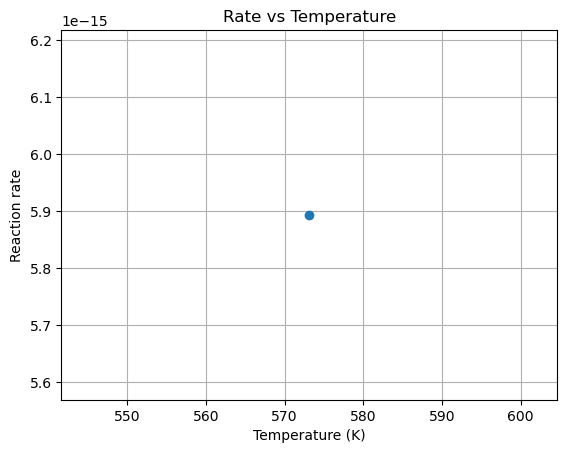

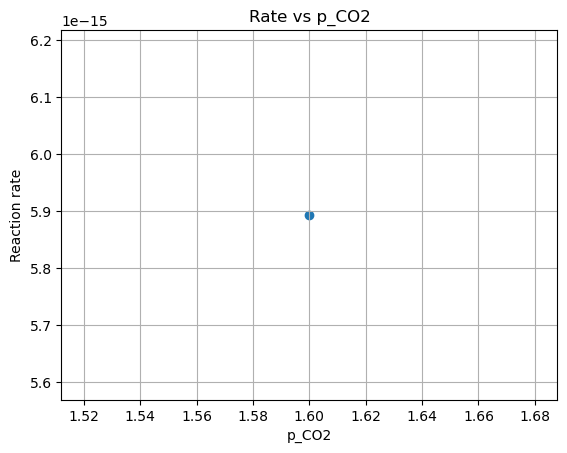

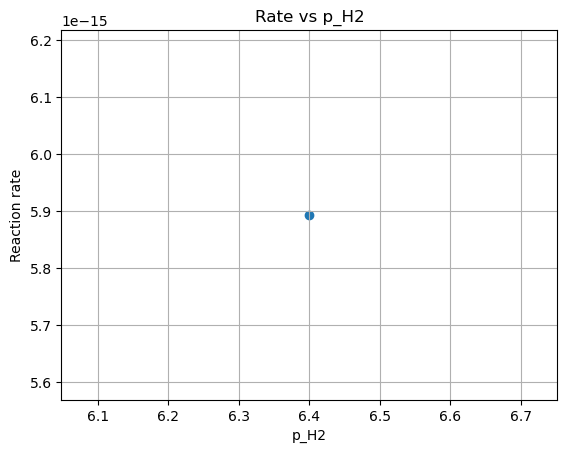

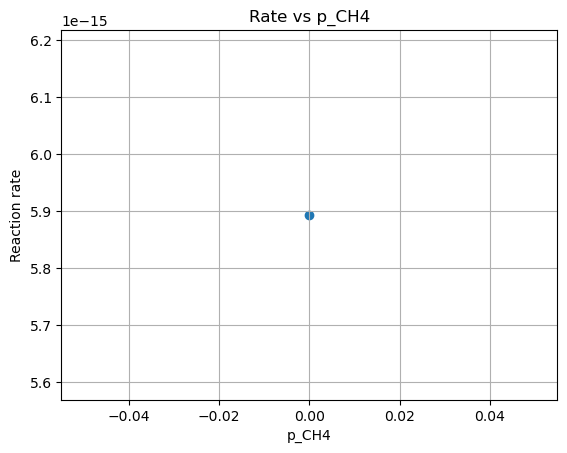

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Koz = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Koz")

# ===============================
# Normalize column names
# ===============================
df_Koz.columns = (
    df_Koz.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ---- Explicit mapping ----
column_map = {
    "k0": "k0",
    "kzero": "k0",
    "k₀": "k0",
    "ea": "Ea",
    "t": "T",
    "aoh": "Aoh",
    "boh": "Boh",
    "ah2": "Ah2",
    "bh2": "Bh2",
    "aeq": "Aeq",
    "beq": "Beq",
    "ceq": "Ceq",
    "amix": "Amix",
    "bmix": "Bmix",
    "ph2": "p_H2",
    "pco2": "p_CO2",
    "pch4": "p_CH4",
    "ph2o": "p_H2O",
}

df_Koz = df_Koz.rename(columns={k: v for k, v in column_map.items() if k in df_Koz.columns})

# ===============================
# Required columns
# ===============================
required = [
    "k0", "Ea", "T",
    "Aeq", "Beq", "Ceq",
    "Aoh", "Boh",
    "Ah2", "Bh2",
    "Amix", "Bmix",
    "p_H2", "p_CO2", "p_CH4", "p_H2O"
]

# ===============================
# Sanity check
# ===============================
missing = [c for c in required if c not in df_Koz.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")
print(f"✅ Columns OK | Rows before cleaning: {len(df_Koz)}")

# ===============================
# Robust numeric cleaning function
# ===============================
def clean_numeric_column(series):
    """
    Converts a pandas Series to numeric safely.
    Handles commas, spaces, hidden characters, invalid entries.
    """
    cleaned = (
        series.astype(str)                  # Make sure it’s string
        .str.replace(",", ".", regex=False) # Comma to dot
        .str.replace(r"[^\d\.\-eE]", "", regex=True)  # Remove non-numeric chars
        .str.strip()                         # Strip spaces
    )
    return pd.to_numeric(cleaned, errors='coerce')   # Convert to float

# ===============================
# Apply cleaning to all required columns
# ===============================
for col in required:
    if col in df_Koz.columns:
        df_Koz[col] = clean_numeric_column(df_Koz[col])

# Drop rows with NaN in required columns
df_Koz = df_Koz.dropna(subset=required).reset_index(drop=True)
print(f"✅ Rows after aggressive cleaning: {len(df_Koz)}")
print(df_Koz.head())

if len(df_Koz) <= 1:
    print("⚠️ Warning: After cleaning, <= 1 valid row. Check Excel data!")

# ===============================
# Koz methanation rate function
# ===============================
def co2_methanation_rate(row):
    T = row["T"]
    k = row["k0"] * np.exp(-row["Ea"] / (R * T))

    K_eq = np.exp(row["Aeq"] + row["Beq"]/T - row["Ceq"]*np.log(T))
    K_OH = np.exp(row["Aoh"] + row["Boh"]/T)
    K_H2 = np.exp(row["Ah2"] + row["Bh2"]/T)
    K_mix = np.exp(row["Amix"] + row["Bmix"]/T)

    driving_force = 1.0 - (
        row["p_CH4"] * row["p_H2O"]**2
    ) / (
        row["p_CO2"] * row["p_H2"]**4 * K_eq
    )

    numerator = (
        k
        * row["p_H2"]**0.5
        * row["p_CO2"]**0.5
        * driving_force
    )

    denominator = (
        1
        + K_OH * (row["p_H2O"] / row["p_H2"]**0.5)
        + K_H2 * row["p_H2"]**0.5
        + K_mix * row["p_CO2"]**0.5
    )**2

    return numerator / denominator

# ===============================
# Run simulations
# ===============================
df_Koz["rate"] = df_Koz.apply(co2_methanation_rate, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_Koz.to_excel(writer, sheet_name="Koz_Results", index=False)

print("✅ Simulation completed | Results saved to 'Koz_Results'")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Koz["T"], df_Koz["rate"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs Temperature")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CO2"], df_Koz["rate"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CO2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_H2"], df_Koz["rate"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_H2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CH4"], df_Koz["rate"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CH4")
plt.show()


✅ Numeric conversion done | Rows: 38
   p_H2  p_CO2  p_CH4  p_H2O       T        k0     Ea   t0    Aeq       Beq  \
0   6.4    1.6      0      0  573.15  0.000035  77500  555  0.203  0.000052   
1   6.4    1.6      0      0     NaN  0.000035  77500  555  0.203  0.000052   
2   6.4    1.6      0      0     NaN  0.000035  77500  555  0.203  0.000052   
3   6.4    1.6      0      0     NaN  0.000035  77500  555  0.203  0.000052   
4   6.4    1.6      0      0     NaN  0.000035  77500  555  0.203  0.000052   

    Ceq  Aoh      Boh   Ah2     Bh2  Amix     Bmix  
0 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
1 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
2 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
3 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
4 -0.25  0.5 -2694.25  0.44  745.73  0.88  1202.79  
✅ Simulation completed | Results saved to 'Koz_Results'


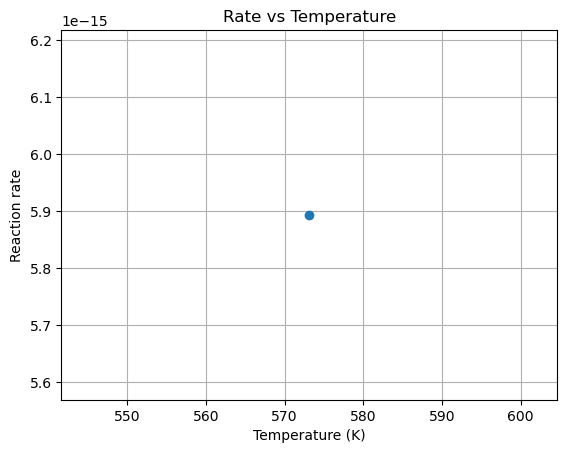

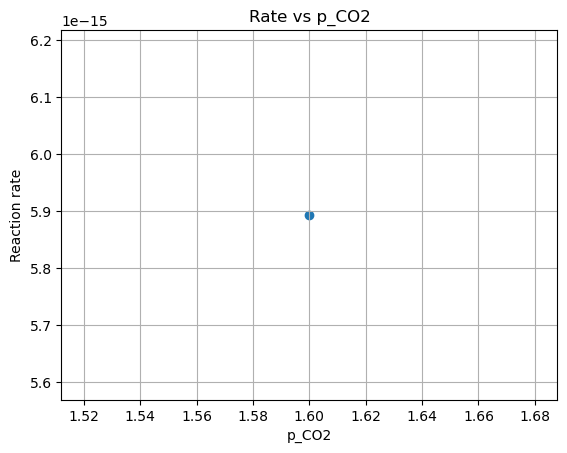

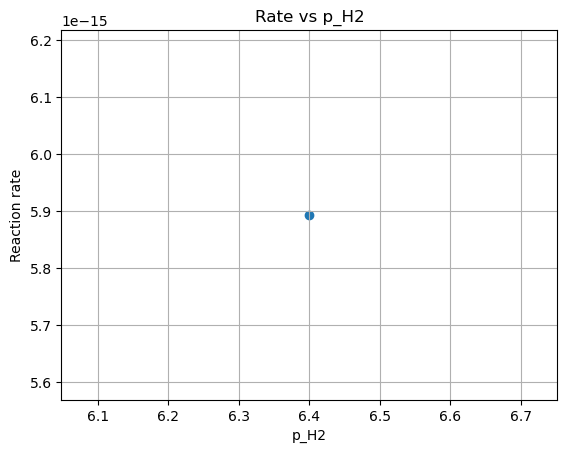

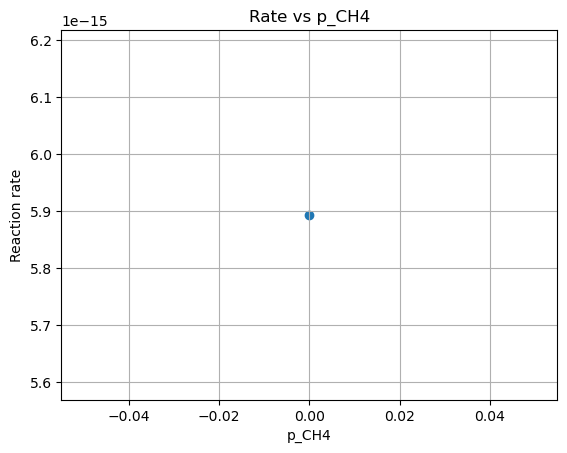

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Koz = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Koz")

# ===============================
# Normalize column names
# ===============================
df_Koz.columns = (
    df_Koz.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ---- Explicit mapping ----
column_map = {
    "k0": "k0",
    "kzero": "k0",
    "k₀": "k0",
    "ea": "Ea",
    "t": "T",
    "aoh": "Aoh",
    "boh": "Boh",
    "ah2": "Ah2",
    "bh2": "Bh2",
    "aeq": "Aeq",
    "beq": "Beq",
    "ceq": "Ceq",
    "amix": "Amix",
    "bmix": "Bmix",
    "ph2": "p_H2",
    "pco2": "p_CO2",
    "pch4": "p_CH4",
    "ph2o": "p_H2O",
}

df_Koz = df_Koz.rename(columns={k: v for k, v in column_map.items() if k in df_Koz.columns})

# ===============================
# Columns needed for rate calculation
# ===============================
needed_for_rate = [
    "k0", "Ea", "T",
    "Aeq", "Beq", "Ceq",
    "Aoh", "Boh",
    "Ah2", "Bh2",
    "Amix", "Bmix",
    "p_H2", "p_CO2", "p_CH4", "p_H2O"
]

# ===============================
# Numeric conversion without dropping rows
# ===============================
def clean_numeric_column(series):
    """
    Converts a pandas Series to numeric safely.
    Handles commas, spaces, hidden characters.
    """
    cleaned = (
        series.astype(str)                  # Ensure string
        .str.replace(",", ".", regex=False) # Convert comma to dot
        .str.replace(r"[^\d\.\-eE]", "", regex=True)  # Remove non-numeric chars
        .str.strip()                         # Strip spaces
    )
    return pd.to_numeric(cleaned, errors='coerce')   # Convert to float

for col in needed_for_rate:
    if col in df_Koz.columns:
        df_Koz[col] = clean_numeric_column(df_Koz[col])

print(f"✅ Numeric conversion done | Rows: {len(df_Koz)}")
print(df_Koz.head())

# ===============================
# Koz methanation rate function
# ===============================
def co2_methanation_rate(row):
    # Skip rows where any essential value is NaN
    if row[needed_for_rate].isna().any():
        return np.nan

    T = row["T"]
    k = row["k0"] * np.exp(-row["Ea"] / (R * T))
    K_eq = (137*T**-3.998*np.exp((158.7*10**3) / (R * T)))
    K_OH = np.exp(row["Aoh"] + row["Boh"]/T)
    K_H2 = np.exp(row["Ah2"] + row["Bh2"]/T)
    K_mix = np.exp(row["Amix"] + row["Bmix"]/T)

    driving_force = 1.0 - (
        row["p_CH4"] * row["p_H2O"]**2
    ) / (
        row["p_CO2"] * row["p_H2"]**4 * K_eq
    )

    numerator = k * row["p_H2"]**0.5 * row["p_CO2"]**0.5 * driving_force
    denominator = (1 + K_OH*(row["p_H2O"]/row["p_H2"]**0.5) + K_H2*row["p_H2"]**0.5 + K_mix*row["p_CO2"]**0.5)**2

    return numerator / denominator

# ===============================
# Run simulations
# ===============================
df_Koz["rate"] = df_Koz.apply(co2_methanation_rate, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_Koz.to_excel(writer, sheet_name="Koz_Results", index=False)

print("✅ Simulation completed | Results saved to 'Koz_Results'")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Koz["T"], df_Koz["rate"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs Temperature")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CO2"], df_Koz["rate"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CO2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_H2"], df_Koz["rate"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_H2")
plt.show()

plt.figure()
plt.scatter(df_Koz["p_CH4"], df_Koz["rate"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CH4")
plt.show()
